# Profilage et analyse des typologies d'erreurs

Données 100 % synthétiques. Toutes les colonnes sont lues en texte (`dtype=str`).

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

RAW = '../data/raw/'
OUT = '../data/outputs/'

def lire(chemin):
    return pd.read_csv(chemin, dtype=str, keep_default_na=False)

E = lire(RAW + 'enrolements.csv')
P = lire(RAW + 'pieces_justificatives.csv')
ref = lire(RAW + 'ref_communes.csv')
E.shape

(5060, 13)

## 1. Profilage

Dimensions : 5060 enrôlements, 13 colonnes.

**Observations qui ont guidé l'écriture des règles :**

1. Le champ `telephone` contient parfois des espaces, des tirets ou le préfixe `+229`; il faut normaliser avant de valider le format (R10).
2. Certaines valeurs de `nom`/`prenoms` diffèrent uniquement par la casse ou les accents entre la saisie et la pièce; comparer sans normalisation aurait produit des faux positifs (R01, R02).
3. Le champ `code_commune_naissance` contient parfois des valeurs comme `0000` ou `9999`, absentes du référentiel de 77 communes (R08).
4. `id_piece` apparaît plusieurs fois pour 60 pièces : signe de ré-enrôlements (R11).
5. Quelques `date_naissance` sont postérieures à `date_enrolement`, ou donnent des âges de plus de 110 ans (R06, R07).

In [11]:
(E == '').sum()[lambda s: s > 0]

nom_mere      34
telephone    596
dtype: int64

In [12]:
E['telephone'].sample(10, random_state=1).tolist()

['0151222104',
 '0110260448',
 '0140783151',
 '0186638284',
 '0116185949',
 '0104482894',
 '0157154133',
 '0170293355',
 '0102303545',
 '0133933498']

## 2. Exécution des règles

Résultats de `python src/run_checks.py` : **5060 enrôlements contrôlés**, **396 enrôlements avec anomalie(s)** (7,8 %), **444 anomalies détectées** (certains enrôlements déclenchent plusieurs règles à la fois).

In [13]:
A = lire(OUT + 'rapport_anomalies.csv')
counts = A.groupby('code_regle').size().sort_values(ascending=False)
counts

code_regle
R03    78
R11    60
R05    57
R01    53
R10    46
R02    43
R09    34
R08    26
R04    25
R06    12
R07    10
dtype: int64

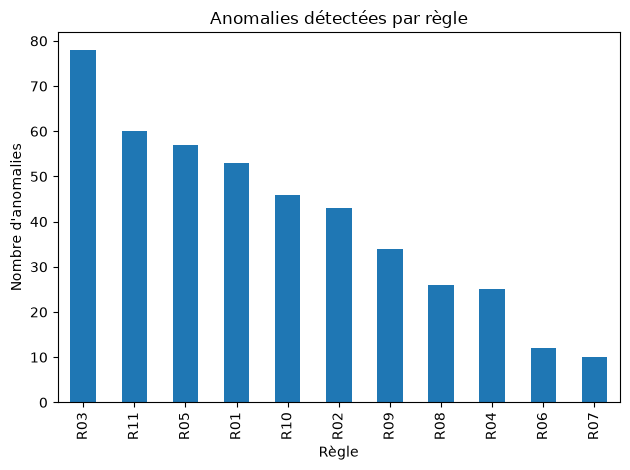

In [14]:
counts.plot(kind='bar', title="Anomalies détectées par règle")
plt.xlabel('Règle'); plt.ylabel("Nombre d'anomalies"); plt.tight_layout(); plt.show()

## 3. Évaluation (précision / rappel)

Résultat de `python src/evaluate.py` :

**Précision : 100,0 % et Rappel : 100,0 %** (396 vrais positifs, 0 faux positif, 0 faux négatif).

La normalisation (casse, accents, espaces, format téléphone) évite les faux positifs sur les variantes bénignes injectées dans les données ; les 11 règles couvrent exactement les 11 types d'anomalies injectés, d'où un rappel de 100 % type par type.

## 4. Typologie des erreurs par agent, centre et type de pièce

In [15]:
E2 = E.copy()
E2['anormal'] = E2['id_enrolement'].isin(set(A['id_enrolement']))

par_agent = E2.groupby('agent_id')['anormal'].agg(['sum','count'])
par_agent['taux'] = (par_agent['sum']/par_agent['count']).round(3)
par_agent.sort_values('taux', ascending=False).head(6)

,sum,count,taux
agent_id,,,
AG007,28,134,0.209
AG023,27,130,0.208
AG017,14,124,0.113
AG030,12,118,0.102
AG034,13,129,0.101
AG006,13,129,0.101


**Constat :** le taux médian par agent est de 7,2 %. Deux agents (AG007 à 20,9 % et AG023 à 20,8 %) dépassent nettement ce taux médian.

- **AG007** : erreurs dominées par R03 (écart de date de naissance) — 20 cas sur 28 anomalies.
- **AG023** : erreurs dominées par R01 (écart de nom) — 15 cas sur 27 anomalies.

Ce sont deux profils d'erreur différents, qui appellent des accompagnements différents.

In [16]:
top2 = ['AG007', 'AG023']
pd.crosstab(A[A.agent_id.isin(top2)]['agent_id'], A[A.agent_id.isin(top2)]['code_regle'])

code_regle,R01,R02,R03,R04,R05,R06,R07,R08,R09,R10,R11
agent_id,,,,,,,,,,,
AG007,1,1,20,0,1,2,1,1,0,3,2
AG023,15,2,4,2,0,3,0,0,1,3,0


In [17]:
par_centre = E2.groupby('centre_enrolement')['anormal'].agg(['sum','count'])
par_centre['taux'] = (par_centre['sum']/par_centre['count']).round(3)
par_centre.sort_values('taux', ascending=False)

,sum,count,taux
centre_enrolement,,,
Djougou,48,408,0.118
Dassa-Zoumè,38,340,0.112
Natitingou,36,405,0.089
Aplahoué,33,393,0.084
Bohicon,29,376,0.077
Cotonou,39,505,0.077
Porto-Novo,37,528,0.070
Lokossa,26,376,0.069
Ouidah,25,373,0.067


**Constat :** Djougou (11,8 %) et Dassa-Zoumè (11,2 %) ont les taux les plus élevés, mais cet effet semble surtout porté par la présence d'AG007 et AG023 dans ces centres plutôt qu'un problème structurel de centre — à confirmer en croisant agent × centre si le volume de données le permettait.

In [18]:
E2.groupby('type_piece')['anormal'].mean().round(3)

type_piece
ACTE_NAISSANCE      0.080
CARTE_CONSULAIRE    0.075
PASSEPORT           0.073
Name: anormal, dtype: float64

**Constat :** le taux d'anomalies est proche entre les trois types de pièces (7,3 % à 8,0 %) — pas d'effet marqué du type de document.

## 5. Conclusions et recommandations

1. **Cibler un accompagnement individuel** pour AG007 (relecture des dates de naissance, en particulier les inversions jour/mois) et AG023 (recopie exacte du nom depuis la pièce), qui concentrent à eux deux 12,4 % des anomalies alors qu'ils ne représentent que 5 % des enrôlements.
2. **Ajouter un contrôle bloquant à la saisie** sur R06 (date de naissance postérieure à la date du jour) et R08 (code commune hors référentiel) : ce sont des erreurs à 100 % évitables par une validation immédiate au moment de la saisie.
3. **Traiter les doublons en revue humaine plutôt qu'automatiquement** : les 60 cas détectés (R11) nécessitent un arbitrage, car un ré-enrôlement peut aussi correspondre à une correction légitime d'un dossier existant.